# 데이터 분석 통계 & 가설검정 종합 복습 문제

---

## 사용 데이터셋

1. **Gym Members Exercise Dataset**
   - 파일명: `gym_members_exercise.csv`

2. **Customer Personality Analysis**
   - 파일명: `marketing_campaign.csv`

In [12]:
import pandas as pd
import numpy as np
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
import platform

# 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

# 마이너스 기호 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False

# 데이터 불러오기
# df_gym = pd.read_csv("gym_members_exercise.csv")
# # marketing_campaign.csv 의 경우 tab으로 구분되어있음.
# df_cust = pd.read_csv("marketing_campaign.csv", sep='\t')

# df_gym.head(), df_gym.columns, df_cust.head(), df_cust.columns


## Q1. Gym 데이터 – 기술통계 & 분포 확인

1. `gym_members_exercise.csv`를 읽어서 `df_gym`이라는 DataFrame으로 저장하세요.
2. 다음 연속형 변수들에 대해 `describe()`로 요약 통계를 구하고,
   평균/중앙값/표준편차를 따로 한 번 더 계산해보세요.
   - `Age`
   - `Weight (kg)`
   - `Height (m)`
   - `Max_BPM`
   - `Avg_BPM`
   - `Resting_BPM`
   - `Session_Duration (hours)`
   - `Calories_Burned`
3. `Gender`별로 `Calories_Burned`의 평균과 표준편차를 비교하세요.
4. `Calories_Burned`에 대해 히스토그램과 박스플롯을 그려 분포 모양과 이상치 여부를 확인하세요.


In [3]:
# 데이터 불러오기
df_gym = pd.read_csv("gym_members_exercise.csv")
df_gym

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
968,24,Male,87.1,1.74,187,158,67,1.57,1364.0,Strength,10.0,3.5,4,3,28.77
969,25,Male,66.6,1.61,184,166,56,1.38,1260.0,Strength,25.0,3.0,2,1,25.69
970,59,Female,60.4,1.76,194,120,53,1.72,929.0,Cardio,18.8,2.7,5,3,19.50
971,32,Male,126.4,1.83,198,146,62,1.10,883.0,HIIT,28.2,2.1,3,2,37.74


In [3]:
# 데이터 타입 및 Null값 등 정보 확인
df_gym.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 973 entries, 0 to 972
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            973 non-null    int64  
 1   Gender                         973 non-null    object 
 2   Weight (kg)                    973 non-null    float64
 3   Height (m)                     973 non-null    float64
 4   Max_BPM                        973 non-null    int64  
 5   Avg_BPM                        973 non-null    int64  
 6   Resting_BPM                    973 non-null    int64  
 7   Session_Duration (hours)       973 non-null    float64
 8   Calories_Burned                973 non-null    float64
 9   Workout_Type                   973 non-null    object 
 10  Fat_Percentage                 973 non-null    float64
 11  Water_Intake (liters)          973 non-null    float64
 12  Workout_Frequency (days/week)  973 non-null    int

In [4]:
# 컬럼 확인
df_gym.columns

Index(['Age', 'Gender', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM',
       'Resting_BPM', 'Session_Duration (hours)', 'Calories_Burned',
       'Workout_Type', 'Fat_Percentage', 'Water_Intake (liters)',
       'Workout_Frequency (days/week)', 'Experience_Level', 'BMI'],
      dtype='object')

In [5]:
# 기술 통계 확인 (범주형까지 전체)
df_gym.describe(include='all')

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
count,973.000000,973,973.000000,973.00000,973.000000,973.000000,973.000000,973.000000,973.000000,973,973.000000,973.000000,973.000000,973.000000,973.000000
unique,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,NaN,NaN,NaN,NaN,NaN
top,NaN,Male,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Strength,NaN,NaN,NaN,NaN,NaN
freq,NaN,511,NaN,NaN,NaN,NaN,NaN,NaN,NaN,258,NaN,NaN,NaN,NaN,NaN
mean,38.683453,NaN,73.854676,1.72258,179.883864,143.766701,62.223022,1.256423,905.422405,NaN,24.976773,2.626619,3.321686,1.809866,24.912127
std,12.180928,NaN,21.207500,0.12772,11.525686,14.345101,7.327060,0.343033,272.641516,NaN,6.259419,0.600172,0.913047,0.739693,6.660879
min,18.000000,NaN,40.000000,1.50000,160.000000,120.000000,50.000000,0.500000,303.000000,NaN,10.000000,1.500000,2.000000,1.000000,12.320000
25%,28.000000,NaN,58.100000,1.62000,170.000000,131.000000,56.000000,1.040000,720.000000,NaN,21.300000,2.200000,3.000000,1.000000,20.110000
50%,40.000000,NaN,70.000000,1.71000,180.000000,143.000000,62.000000,1.260000,893.000000,NaN,26.200000,2.600000,3.000000,2.000000,24.160000
75%,49.000000,NaN,86.000000,1.80000,190.000000,156.000000,68.000000,1.460000,1076.000000,NaN,29.300000,3.100000,4.000000,2.000000,28.560000


In [6]:
# 연속형 변수들의 평균/중앙값/표준편차를 따로 한 번 더 계산
print(f"Age 평균: {df_gym['Age'].mean():.2f}세, 중앙값: {df_gym['Age'].median():.2f}세, 표준편차: {df_gym['Age'].std():.2f}세")
print(f"Weight 평균: {df_gym['Weight (kg)'].mean():.2f}(kg), 중앙값: {df_gym['Weight (kg)'].median():.2f}(kg), 표준편차: {df_gym['Weight (kg)'].std():.2f}(kg)")
print(f"Height 평균: {df_gym['Height (m)'].mean():.2f}(m), 중앙값: {df_gym['Height (m)'].median():.2f}(m), 표준편차: {df_gym['Height (m)'].std():.2f}(m)")
print(f"Max_BPM 평균: {df_gym['Max_BPM'].mean():.2f}, 중앙값: {df_gym['Max_BPM'].median():.2f}, 표준편차: {df_gym['Max_BPM'].std():.2f}")
print(f"Avg_BPM 평균: {df_gym['Avg_BPM'].mean():.2f}, 중앙값: {df_gym['Avg_BPM'].median():.2f}, 표준편차: {df_gym['Avg_BPM'].std():.2f}")
print(f"Resting_BPM 평균: {df_gym['Resting_BPM'].mean():.2f}, 중앙값: {df_gym['Resting_BPM'].median():.2f}, 표준편차: {df_gym['Resting_BPM'].std():.2f}")
print(f"Session_Duration 평균: {df_gym['Session_Duration (hours)'].mean():.2f}(hours), 중앙값: {df_gym['Session_Duration (hours)'].median():.2f}(hours), 표준편차: {df_gym['Session_Duration (hours)'].std():.2f}(hours)")
print(f"Calories_Burned 평균: {df_gym['Calories_Burned'].mean():.2f}, 중앙값: {df_gym['Calories_Burned'].median():.2f}, 표준편차: {df_gym['Calories_Burned'].std():.2f}")

Age 평균: 38.68세, 중앙값: 40.00세, 표준편차: 12.18세
Weight 평균: 73.85(kg), 중앙값: 70.00(kg), 표준편차: 21.21(kg)
Height 평균: 1.72(m), 중앙값: 1.71(m), 표준편차: 0.13(m)
Max_BPM 평균: 179.88, 중앙값: 180.00, 표준편차: 11.53
Avg_BPM 평균: 143.77, 중앙값: 143.00, 표준편차: 14.35
Resting_BPM 평균: 62.22, 중앙값: 62.00, 표준편차: 7.33
Session_Duration 평균: 1.26(hours), 중앙값: 1.26(hours), 표준편차: 0.34(hours)
Calories_Burned 평균: 905.42, 중앙값: 893.00, 표준편차: 272.64


In [7]:
# Gender별로 Calories_Burned의 평균 비교
df_gym.groupby('Gender')['Calories_Burned'].mean()

Gender
Female    862.248918
Male      944.455969
Name: Calories_Burned, dtype: float64

In [8]:
# Gender별로 Calories_Burned의 표준편차 비교
df_gym.groupby('Gender')['Calories_Burned'].std()

Gender
Female    249.614915
Male      286.590987
Name: Calories_Burned, dtype: float64

In [39]:
# 간단한 방법
cols = ["Age", "Weight (kg)", "Height (m)",
        "Max_BPM", "Avg_BPM", "Resting_BPM",
        "Session_Duration (hours)", "Calories_Burned"]
print(df_gym[cols].describe())

print(df_gym.groupby("Gender")["Calories_Burned"].agg(["mean", "std", "count"]))

              Age  Weight (kg)  Height (m)     Max_BPM     Avg_BPM  \
count  973.000000   973.000000   973.00000  973.000000  973.000000   
mean    38.683453    73.854676     1.72258  179.883864  143.766701   
std     12.180928    21.207500     0.12772   11.525686   14.345101   
min     18.000000    40.000000     1.50000  160.000000  120.000000   
25%     28.000000    58.100000     1.62000  170.000000  131.000000   
50%     40.000000    70.000000     1.71000  180.000000  143.000000   
75%     49.000000    86.000000     1.80000  190.000000  156.000000   
max     59.000000   129.900000     2.00000  199.000000  169.000000   

       Resting_BPM  Session_Duration (hours)  Calories_Burned  
count   973.000000                973.000000       973.000000  
mean     62.223022                  1.256423       905.422405  
std       7.327060                  0.343033       272.641516  
min      50.000000                  0.500000       303.000000  
25%      56.000000                  1.040000     

### 시각화 함수 (Q-Q plot, 히스토그램+왜도/첨도, 박스플롯)

In [112]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

def plot_qqplot_hist_box(data):
    """
    Q-Q Plot + 히스토그램 + 박스플롯을 자동으로 생성해 보여주는 함수
    (문자 → 숫자 변환, NaN 제거 포함, subplot 자동 생성)
    """

    # 데이터 클리닝 - 숫자 변환 및 NaN 제거
    clean_data = pd.to_numeric(data, errors='coerce').dropna()

    # subplot 생성
    fig, (ax_qq, ax_hist, ax_box) = plt.subplots(3, 1, figsize=(6, 8))

    # Q-Q Plot
    stats.probplot(clean_data, dist="norm", plot=ax_qq)
    ax_qq.set_title("Q-Q Plot", fontsize=13, fontweight="bold")
    ax_qq.grid(alpha=0.3)

    # 포인트 & 45도 선 꾸미기
    ax_qq.get_lines()[0].set_markerfacecolor("blue")
    ax_qq.get_lines()[0].set_markersize(4)
    ax_qq.get_lines()[1].set_color("red")
    ax_qq.get_lines()[1].set_linewidth(2)

    # 히스토그램
    ax_hist.hist(clean_data, bins=30, density=True, alpha=0.6,
                 color="skyblue", edgecolor="black")

    # KDE
    kde_x = np.linspace(clean_data.min(), clean_data.max(), 100)
    kde = stats.gaussian_kde(clean_data)
    ax_hist.plot(kde_x, kde(kde_x), "b-", label="KDE")

    # 정규분포
    norm_x = np.linspace(clean_data.min(), clean_data.max(), 100)
    norm_y = stats.norm.pdf(norm_x, np.mean(clean_data), np.std(clean_data))
    ax_hist.plot(norm_x, norm_y, "r--", label="정규분포")

    ax_hist.set_title("Histogram & KDE", fontsize=13, fontweight="bold")
    ax_hist.grid(alpha=0.3)
    ax_hist.legend()

    # 왜도·첨도 박스
    ax_hist.text(0.02, 0.98,
                 f"왜도: {stats.skew(clean_data):.3f}\n첨도: {stats.kurtosis(clean_data):.3f}",
                 transform=ax_hist.transAxes,
                 verticalalignment="top",
                 bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.7))

    # Box Plot
    ax_box.boxplot(clean_data,
                   vert=False,
                   patch_artist=True,
                   boxprops=dict(facecolor="lightyellow", color="black"),
                   medianprops=dict(color="red", linewidth=2),
                   whiskerprops=dict(color="black"),
                   capprops=dict(color="black"),
                   flierprops=dict(marker="o", markerfacecolor="orange", markersize=5))

    ax_box.set_title("Box Plot", fontsize=13, fontweight="bold")
    ax_box.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

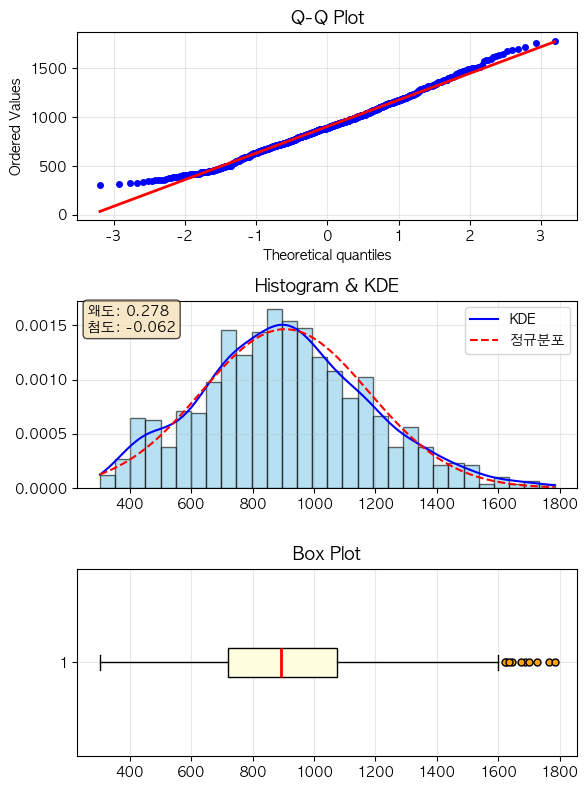

In [ ]:
# 함수 호출(Calories_Burned 분포 시각화)
plot_qqplot_hist_box(df_gym['Calories_Burned'])

### 해석

- Q–Q Plot
  - 중간 지점들은 정규분포 기준선에 잘 맞음 → 대부분 정규 형태
  - 상위 끝부분이 기준선보다 위로 올라감 → 고칼로리 값에서 양의 왜도(오른쪽 꼬리)
  - 극단적으로 높은 칼로리 소비 세션이 일부 존재함을 시사

- Histogram + KDE
  - 전반적 형태는 종 모양(정규분포)에 가까우나 약간 우측 왜도
    - 왜도 = 0.278 → 정규분포보다 오른쪽 꼬리가 약간 긴 분포
    - 첨도 = −0.062 → 정규분포와 거의 비슷한 꼬리 두께
  - 700~1100kcal 구간이 중심부에서 가장 빈도가 높음
  - 1500kcal 이상에서 소수의 값들이 늘어져 있음 → 고강도·장시간 운동으로 추정

- Box Plot
  - IQR(중앙 50%) ≈ 750–1100 kcal
  - 중앙값은 약 900kcal
  - 우측에 많은 이상치 존재 → 고칼로리 세션이 분포 왜곡
  - 좌측은 이상치 거의 없음 → 하한 방향으로는 이상치 적음

- 종합 해석
  - 전체 분포는 대체로 정규분포에 가까우나 약한 양의 왜도(오른쪽 꼬리) 존재
  - 칼로리가 높은 일부 세션이 분포를 오른쪽으로 끌어올리고 있음
  - 대부분의 운동 세션은 700~1100kcal 범위에서 발생하는 비교적 안정적인 패턴


## Q2. Gym 데이터 – `Calories_Burned` 정규성 검정

1. `Calories_Burned`가 정규분포에서 왔다고 볼 수 있는지 Shapiro–Wilk 정규성 검정을 수행하세요.
2. 같은 데이터에 대해 Q–Q plot을 그려 시각적으로도 확인해 보세요.
3. 유의수준 0.05 기준으로 정규성을 기각할 수 있는지, 실무적인 표현으로 해석을 적어 보세요.

- H0: `Calories_Burned`는 정규분포에서 온 표본이다.
- H1: 정규분포에서 온 표본이 아니다.


### 정규성 검정 함수 (Shapiro–Wilk)

In [ ]:
def shapiro_test(data):
    """
    Shapiro–Wilk 정규성 검정 함수
    """
    # 숫자 변환 및 NaN 제거
    df_clean = pd.to_numeric(data, errors='coerce').dropna()

    # shapiro 검정
    stat, p_value = stats.shapiro(df_clean)
    
    # 결과 출력
    result = (
        f"Shapiro-Wilk 통계량 = {stat:.3f}, p-value = {p_value:.3f}\n"
        f"{'귀무가설 기각 (정규분포 아님)' if p_value < 0.05 else '귀무가설 채택 (정규분포 가정 충족)'}"        
    )
    return result

In [72]:
# Calories_Burned에 대해 Shapiro–Wilk 정규성 검정
print(shapiro_test(df_gym['Calories_Burned']))

Shapiro-Wilk 통계량 = 0.992, p-value = 0.0000
귀무가설 기각 (정규분포 아님)


### 해석

- Shapiro-Wilk 통계량 = 0.992, p-value = 0.000
  - p-value → 유의수준 0.05보다 훨씬 작음 → 귀무가설 기각 → 데이터는 정규분포를 따르지 않음 → 비모수 검정 고려
- Q-Q Plot
  - 중앙 구간은 대체로 잘 맞지만 양쪽 꼬리 부분에서 점들이 빨간 기준선에서 벗어남 → 꼬리 부분이 정규분포보다 두꺼움 (heavy tail) → 비정규성의 전형적 패턴
- 결론
  - 분포가 정규 가정을 벗어나므로, 이후 비교 분석에서는 정규분포 기반의 t-test나 ANOVA보다 비모수 방식(예: Mann–Whitney, Kruskal–Wallis)을 적용하는 것이 적절함
  - 특히 상위 구간에 극단값이 존재하는 특성을 고려하면, 중앙값 기준의 비모수 검정이 실제 패턴을 더 안정적으로 반영할 가능성이 높음


## Q3. 단일표본 t-검정 – 평균 소모 칼로리가 500kcal인가?

헬스장에서 "회원 1회 운동 세션 평균 칼로리 소모량은 500kcal" 라고 홍보한다고 가정합시다.

1. 다음과 같이 가설을 세우고 단일표본 t-검정을 수행하세요.
   - H0: μ = 500
   - H1: μ ≠ 500
2. `Calories_Burned`에 대해 `stats.ttest_1samp`를 사용하세요.
3. 유의수준 0.05에서 H0를 기각할 수 있는지 판단하고, 홍보 문구와 모순되는지/괜찮은지 해석을 적어 보세요.


### 가설 설정

   - H0: μ = 500 (회원 1회 운동 세션 평균 칼로리 소모량은 500kcal이다.)
   - H1: μ ≠ 500 (회원 1회 운동 세션 평균 칼로리 소모량은 500kcal이 아니다.)

### 단일표본 t-검정 함수 (양측, 단측 포함)

In [ ]:
from scipy.stats import ttest_1samp

def ttest_1samp_alt_def(data, popmean, alternative='two-sided'):
    
    t_stat, p_value = ttest_1samp(data, popmean, alternative=alternative)
    
    if alternative == 'two-sided':
        conclusion = (
            f"귀무가설 기각 → 평균이 {popmean}과 다르다." if p_value < 0.05 
            else f"귀무가설 채택 → 평균이 {popmean}과 다르다고 보기 어렵다."
        )
    
    elif alternative == 'less':
        conclusion = (
            f"귀무가설 기각 → 평균이 {popmean}보다 작다." if p_value < 0.05 
            else f"귀무가설 채택 → 평균이 {popmean}보다 작다고 볼 수 없다."
        )
        
    else : # alternative=greater
        conclusion = (
            f"귀무가설 기각 → 평균이 {popmean}보다 크다." if p_value < 0.05 
            else f"귀무가설 채택 → 평균이 {popmean}보다 크다고 볼 수 없다."
        )

    result = (
        f"t-stat = {t_stat:.3f}, p-value = {p_value:.3f}\n{conclusion}"
    )
    
    return result

In [ ]:
# Calories_Burned 단일표본 t-검정 결과 (양측)
print(ttest_1samp_alt_def(df_gym['Calories_Burned'], 500))

t-stat = 46.384, p-value = 0.000
귀무가설 기각 → 평균이 500과 다르다.


In [39]:
# Calories_Burned 단일표본 t-검정 결과 (단측)
print(ttest_1samp_alt_def(df_gym['Calories_Burned'], 500, alternative='less'))

t-stat = 46.384, p-value = 1.000
귀무가설 채택 → 평균이 500보다 작다고 볼 수 없다.


In [41]:
# Calories_Burned 단일표본 t-검정 결과 (단측)
print(ttest_1samp_alt_def(df_gym['Calories_Burned'], 500, alternative='greater'))

t-stat = 46.384, p-value = 0.000
귀무가설 기각 → 평균이 500보다 크다.


### 해석

- 단일표본 t-검정 결과
  - 양측 검정 결과
    - t=46.384(t≈10 이상이면 매우 큰 차이), p-value = 0.000 → 유의수준 0.05보다 작으므로 귀무가설 기각 → 평균 칼로리 소모량이 500kcal과 통계적으로 유의하게 다르다.
  - 단측 검정(greater) 결과
    - p-value = 0.000 → 유의수준 0.05보다 작으므로 귀무가설(μ ≤ 500) 기각 → 평균 칼로리 소모량은 500kcal보다 크다.

- 홍보 문구와의 관계
  - 실제 평균이 500kcal 수준과 크게 차이가 나므로, “1회 평균 소모 칼로리 = 500kcal”라는 홍보 문구는 현재 데이터와 부합하지 않음
  - 오히려 실제 평균 칼로리 소모량은 더 크므로, 기준을 상향해 홍보하면 더 효과적일 수 있음

## Q4. 독립표본 t-검정 – 성별에 따른 세션 시간 차이

1. `Gender`가 남/여(Male/Female) 두 그룹인 행만 사용해서,
   - 그룹1: Male
   - 그룹2: Female  
   의 `Session_Duration (hours)`를 비교하세요.
2. 먼저 Levene 등분산성 검정을 수행하여 두 집단 분산이 같은지 확인하세요.
3. Levene p-value를 보고 `equal_var=True/False`를 결정한 뒤, `stats.ttest_ind`로 독립표본 t-검정을 수행하세요.
4. 유의수준 0.05에서 성별에 따라 평균 세션 시간이 유의하게 다른지, 어느 쪽이 더 긴지 해석해 보세요.


### 가설 설정

- 등분산성 검정 가설
   - H0: 등분산 가정 만족 (남/여 회원의 세션 시간 분산은 같다.)
   - H1: 등분산 가정 불만족 (남/여 회원의 세션 시간 분산은 다르다.)

-  독립표본 t-검정 가설
   - H0: 남/여 회원의 평균 세션 시간은 같다.
   - H1: 남/여 회원의 평균 세션 시간은 다르다.

### 데이터 준비

In [ ]:
# 남/여 그룹별 Session_Duration (hours) 비교
male = df_gym[df_gym['Gender']=='Male']['Session_Duration (hours)']
male.name = "Male" # 각 시리즈에 직접 라벨 붙이기 (추후 평균 결과 출력 시 심플하게 나오기 위함)

female = df_gym[df_gym['Gender']=='Female']['Session_Duration (hours)']
female.name = "Female"

### 등분산성 검정(Levene), 독립표본 t-검정 함수

In [89]:
from scipy.stats import ttest_ind, levene

def levene_ttest_ind_def(g1, g2, center="mean"):
    
    # NaN 제거
    g1 = g1.dropna()
    g2 = g2.dropna()

    # 그룹 이름 자동 추출 (추후 평균 결과 출력 시 심플하게 나오기 위함)
    label1 = g1.name or "Group1"
    label2 = g2.name or "Group2"
    
    # 등분산성 검정(Levene)
    stat_levene, p_levene = levene(g1, g2, center=center)
    equal_var = p_levene >= 0.05
    
    levene_result = (
        f"Levene 등분산성 검정=======================================\n"
        f"Levene p-value = {p_levene:.3f}\n"
        f"{'귀무가설 채택 (등분산 가정 만족) → 기본 t-test 적용' if equal_var else '귀무가설 기각 (등분산 가정 불만족) → Welch t-test 적용'}\n"
    )

    # 독립표본 t-검정
    t_stat, p_value = ttest_ind(g1, g2, equal_var=equal_var)

    ttest_ind_result = (
        f"독립표본 t-검정============================================\n"
        f"t-stat = {t_stat:.3f}, p-value = {p_value:.3f}\n"
        f"{label1} 평균 = {g1.mean():.2f}, {label2} 평균 = {g2.mean():.2f}\n"
        f"{'귀무가설 기각 → 두 집단 평균은 다르다.' if p_value < 0.05 else '귀무가설 채택 → 두 집단 평균은 유의하게 다르지 않다.'}"
    )
    
    return levene_result + "\n" + ttest_ind_result


In [90]:
# 성별에 따라 평균 세션 시간이 유의하게 다른지 등분산성, 독립표본 t-검정
print(levene_ttest_ind_def(male, female))

Levene 등분산성 검정=======================================
Levene p-value = 0.928
귀무가설 채택 (등분산 가정 만족) → 기본 t-test 적용

독립표본 t-검정============================================
t-stat = -0.380, p-value = 0.704
Male 평균 = 1.25, Female 평균 = 1.26
귀무가설 채택 → 두 집단 평균은 유의하게 다르지 않다.


### 해석

- Levene 검정 결과
  - p = 0.928 → 유의수준 0.05보다 크므로 귀무가설 채택 → 남성과 여성 회원의 세션 시간 분산은 통계적으로 차이가 없어 등분산 가정이 충족됨
- 등분산을 가정한 독립표본 t-검정
  - t = -0.380, p = 0.704 → 유의수준 0.05보다 크므로 귀무가설 채택 → 남성과 여성 회원의 평균 세션 시간 차이가 유의하지 않음
- 따라서 남성과 여성 회원의 평균 세션 시간은 통계적으로 유의한 차이가 없으므로 어느 쪽이 더 길다고 결론 내릴 수 없다.

## Q5. 대응표본 t-검정 – 운동 전후 심박수 차이

`Resting_BPM`을 운동 전 심박수, `Max_BPM`을 운동 중 최대 심박수라고 보고 같은 사람의 전/후 데이터라고 가정합시다.

1. `diff = Max_BPM - Resting_BPM`를 계산하세요.
2. 이 차이값에 대해 Shapiro–Wilk 정규성 검정을 수행하세요.
3. 다음 가설로 대응표본 t-검정을 수행하세요.
   - H0: 평균 차이 = 0
   - H1: 평균 차이 ≠ 0
4. 유의수준 0.05에서 운동이 심박수를 유의하게 올려주는지 해석해 보세요.


### 가설 설정

- 정규성 검정 가설
   - H0: 정규성 가정 만족 (전후 차이값은 정규분포를 따른다.)
   - H1: 정규성 가정 불만족 (전후 차이값은 정규분포를 따르지 않는다.)

- 대응표본 t-검정 가설
   - H0: 전후 평균에 통계적으로 유의한 차이가 없다.
   - H1: 전후 평균에 통계적으로 유의한 차이가 있다.

- 비모수 검정 (Wilcoxon Signed-Rank) 가설
   - H0: 전후 중앙값에 통계적으로 유의한 차이가 없다.
   - H1: 전후 중앙값에 통계적으로 유의한 차이가 있다.

### 대응표본 t-검정 함수 (정규성 가정 불만족 시 wilcoxon 부호순위 검정)

In [ ]:
from scipy.stats import ttest_rel, shapiro, wilcoxon

def ttest_rel_def(before, after):

    # 차이 계산
    diff = after - before
    
    # NaN 제거
    diff = diff.dropna()

    # 정규성 검정
    stat, sh_p_value = shapiro(diff)
    normal = sh_p_value >= 0.05
    
    shapiro_result = (
        f"Shapiro 정규성 검정=============================================\n"
        f"p-value = {sh_p_value:.3f}\n"
        f"{'귀무가설 채택 (정규성 가정 만족) → 대응표본 t-test 적용' if normal else '귀무가설 기각 (정규성 불만족) → 비모수 검정 (Wilcoxon Signed-Rank) 진행'}\n"
    )
    
    # 가설 검정 
    if normal: # 대응표본 t-test (정규성 가정 만족 시)
        t_stat, p_value = ttest_rel(before, after)

        ttest_rel_result = (
            f"대응표본 t-검정==================================================\n"
            f"t-stat = {t_stat:.3f}, p-value = {p_value:.3f}\n"
            f"{'귀무가설 기각 → 전후 평균에 통계적으로 유의한 차이가 있다.' if p_value < 0.05 else '귀무가설 채택 → 전후 평균에 통계적으로 유의한 차이가 없다.'}"
        )
    else: # 비모수 검정 (Wilcoxon Signed-Rank)
        w_stat, p_value = wilcoxon(diff)

        ttest_rel_result = (
            f"Wilcoxon 부호순위 검정===========================================\n"
            f"W-stat = {w_stat:.3f}, p-value = {p_value:.3f}\n"
            f"{'귀무가설 기각 → 전후 중앙값에 통계적으로 유의한 차이가 있다.' if p_value < 0.05 else '귀무가설 채택 → 전후 중앙값에 통계적으로 유의한 차이가 없다.'}"
        )
    
    return shapiro_result + "\n" + ttest_rel_result


In [111]:
# 운동이 심박수를 유의하게 올려주는지 가설 검정 (정규성 검정 → 대응표본 t-검정 또는 wilcoxon 부호순위 검정)
before = df_gym['Resting_BPM']
after  = df_gym['Max_BPM']
print(ttest_rel_def(before, after))

Shapiro 정규성 검정=============================================
p-value = 0.000
귀무가설 기각 (정규성 불만족) → 비모수 검정 (Wilcoxon Signed-Rank) 진행

Wilcoxon 부호순위 검정===========================================
W-stat = 0.000, p-value = 0.000
귀무가설 기각 → 전후 중앙값에 통계적으로 유의한 차이가 있다.


### 해석

- Shapiro 정규성 검정 결과
  - p = 0.000 → 유의수준 0.05보다 작으므로 귀무가설 기각 (정규성 불만족) → 차이값이 정규분포를 따르지 않음 → 비모수 검정(Wilcoxon Signed-Rank) 사용이 적절함

- Wilcoxon 부호순위 검정 결과
  - p = 0.000 → 유의수준 0.05보다 작으므로 귀무가설 기각 → 운동 전후 심박수의 중앙값에 통계적으로 유의한 차이가 있다.

- 따라서 운동 전후 심박수에는 통계적으로 유의한 차이가 있으므로, 운동이 심박수를 유의하게 올려준다고 결론 내릴 수 있다.

## Q6. 일원 ANOVA – 경험 수준에 따른 칼로리 소모 차이

`Experience_Level`이 (예: Beginner / Intermediate / Advanced 등) 회원의 운동 경험 수준이라고 가정합니다.

1. `Experience_Level`의 각 수준별로 `Calories_Burned`를 나누어 그룹 리스트를 만드세요.
2. 다음 가설로 일원 ANOVA를 수행하세요.
   - H0: 모든 경험 수준 그룹의 모평균 칼로리 소모가 같다.
   - H1: 적어도 한 그룹의 모평균은 다르다.
3. F-statistic과 p-value를 보고 유의수준 0.05에서 결론을 내리세요.
4. (선택) Levene 검정과 Tukey HSD 사후검정으로 분산/어떤 그룹끼리 차이가 나는지도 확인해 보세요.


### 가설 설정

- 정규성 검정 가설
   - H0: 정규성 가정 만족 (각 운동 수준별 칼로리 소모량은 정규분포를 따른다.)
   - H1: 정규성 가정 불만족 (적어도 한 그룹은 정규분포를 따르지 않는다.)

- 등분산성 검정 가설
   - H0: 등분산 가정 만족 (운동 수준별 칼로리 소모량의 분산은 모두 같다.)
   - H1: 등분산 가정 불만족 (운동 수준별 칼로리 소모량의 분산은 다르다.)

- 일원 ANOVA / Welch ANOVA 검정 가설
   - H0: 모든 운동 수준 그룹의 평균 칼로리 소모량은 같다.
   - H1: 적어도 한 그룹의 평균 칼로리 소모량은 다르다.

- 비모수 검정 (Kruskal–Wallis) 가설
   - H0: 모든 운동 수준 그룹의 칼로리 소모량 중앙값은 같다.
   - H1: 적어도 한 그룹의 중앙값은 다르다.

### One-way ANOVA + Tukey / Kruskal–Wallis + Dunn Test 자동판별 함수

In [ ]:
import pandas as pd
from scipy import stats
import pingouin as pg
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import scikit_posthocs as sp


def anova_full_def(df, group_col, value_col):
    """
    일원 ANOVA 자동 분기:
    - 정규성 OK + 등분산 OK → One-way ANOVA + Tukey HSD
    - 정규성 OK + 등분산 NO → Welch ANOVA + Games-Howell
    - 정규성 NO → Kruskal–Wallis + Dunn (Bonferroni)
    """

    # return을 위한 변수 준비
    test_name = None
    result_detail = None
    p_value = None # p_value가 만들어지지 않았는데 p_value를 return하려 하면 NameError 발생 -> p_value 변수를 함수 초반에 미리 초기화

    # 1) 그룹 리스트 생성
    levels = df[group_col].dropna().unique()
    groups = [df[df[group_col] == level][value_col].dropna() for level in levels]
    
    # 2) Shapiro–Wilk 정규성 검정 (각 그룹별)
    shapiro_p = [stats.shapiro(g)[1] for g in groups] # 검정 결과에서 p-value만 꺼내기
    normal_all = all(p >= 0.05 for p in shapiro_p) # Shapiro는 그룹 하나씩 검정하므로 all() 함수 필요

    print("Shapiro 정규성 검정====================================")
    print(f"그룹별 p-value 리스트: {shapiro_p}")
    print(f"{'귀무가설 채택 (모든 그룹이 정규성을 만족) → 등분산성 검정 진행' if normal_all else '귀무가설 기각 (적어도 한 그룹이 정규성 불만족) → 비모수 검정 (Kruskal–Wallis) 진행'}\n")

    # 3) Levene 등분산 검정 (정규성 만족 시만)
    if normal_all:
        levene_res = stats.levene(*groups)
        levene_p = levene_res.pvalue
        equal_var = levene_p >= 0.05

        print("Levene 등분산성 검정===================================")
        print(f"p-value = {levene_p:.4f}")
        print("→ 등분산 가정 만족 → One-way ANOVA 진행" if equal_var else "→ 등분산 가정 불만족 → Welch ANOVA 진행")
        print()
    else:
        equal_var = False

    # 4) 정규성/등분산 여부에 따른 검정 분기
    # ------------------------------------------------------------------

    # Case A: One-way ANOVA (모두 정규 & 등분산)
    if normal_all and equal_var:
        test_name = "anova"
        anova_res = stats.f_oneway(*groups)
        result_detail = anova_res
        f_stat = anova_res.statistic
        p_value = anova_res.pvalue

        print("One-way ANOVA 결과======================================")
        print(f"F = {f_stat:.4f}, p = {p_value:.4f}")
        print(f"{'귀무가설 채택 (모든 그룹의 평균은 같다)' if p_value >= 0.05 else '귀무가설 기각 (적어도 한 그룹의 평균은 다르다) → Tukey 사후검정 진행'}\n")

        if p_value < 0.05:

            # Tukey 사후검정
            clean_df = df[[group_col, value_col]].dropna()

            tukey = pairwise_tukeyhsd(
            endog=clean_df[value_col],
            groups=clean_df[group_col]
            )

            print("\n=== Tukey HSD ===")
            print(tukey.summary())
        else:
            print("→ 유의하지 않음")

    # Case B: Welch ANOVA (정규 yes & 등분산 no)
    elif normal_all and not equal_var:
        test_name = "welch"
        welch_res = pg.welch_anova(dv=value_col, between=group_col, data=df)
        result_detail = welch_res
        f_stat = welch_res['F'][0]
        p_value = welch_res['p-unc'][0]
        
        print("Welch ANOVA 결과========================================")
        print(f"F = {f_stat:.4f}, p = {p_value:.4f}")
        print(f"{'귀무가설 채택 (모든 그룹의 평균은 같다)' if p_value >= 0.05 else '귀무가설 기각 (적어도 한 그룹의 평균은 다르다) → Games-Howell 사후검정 진행'}\n")

        if p_value < 0.05:

            # Games-Howell 사후검정
            clean_df = df[[group_col, value_col]].dropna()
            gh = pg.pairwise_gameshowell(dv=value_col, between=group_col, data=clean_df)

            print("\n=== Games-Howell ===")
            print(gh)
        else:
            print("→ 유의하지 않음")

    # Case C: Kruskal–Wallis (정규성 불만족)
    else:
        test_name = "kruskal"
        kw_res = stats.kruskal(*groups)
        result_detail = kw_res
        h_stat = kw_res.statistic
        p_value = kw_res.pvalue

        print("\n" + "="*60)
        print("Kruskal–Wallis 결과")
        print("="*60)
        print(f"H = {h_stat:.4f}, p = {p_value:.4f}")
        print(f"{'귀무가설 채택 (모든 그룹의 중앙값은 같다)' if p_value >= 0.05 else '귀무가설 기각 (적어도 한 그룹의 중앙값은 다르다) → Dunn 사후검정 진행'}\n")

        if p_value < 0.05:
            dunn = sp.posthoc_dunn(
                df,
                val_col=value_col,
                group_col=group_col,
                p_adjust='bonferroni'
            )
            print("\n=== Dunn Test (Bonferroni) ===")
            print(dunn)
        else:
            print("→ 유의하지 않음")
            
    return test_name, p_value, result_detail


In [ ]:
# 경험 수준에 따른 칼로리 소모 차이 검정
test_name, p_value, result_detail = anova_full_def(df_gym, 'Experience_Level', 'Calories_Burned')

Shapiro 정규성 검정====================================
그룹별 p-value 리스트: [np.float64(0.04000205328124727), np.float64(0.0019175434548939884), np.float64(8.911878907556502e-06)]
귀무가설 기각 (적어도 한 그룹이 정규성 불만족) → 비모수 검정 (Kruskal–Wallis) 진행


Kruskal–Wallis 결과
H = 459.4896, p = 0.0000
귀무가설 기각 (적어도 한 그룹의 중앙값은 다르다) → Dunn 사후검정 진행


=== Dunn Test (Bonferroni) ===
               1             2              3
1   1.000000e+00  8.226672e-20  1.943578e-101
2   8.226672e-20  1.000000e+00   3.779458e-45
3  1.943578e-101  3.779458e-45   1.000000e+00


### 해석

- 정규성 검정(Shapiro) 결과
  - p < 0.05 → 귀무가설 기각 (모든 그룹이 정규분포 따르지 않음) → ANOVA 검정 불가 → 비모수 대안인 Kruskal–Wallis 검정 실시

- 비모수 검정(Kruskal–Wallis) 결과
  - p < 0.05 → 귀무가설 기각 (적어도 하나의 운동 경험 수준 그룹이 다른 그룹과 칼로리 소모량이 다름)

- Dunn 사후검정 결과 (Bonferroni 보정)
  - p < 0.05 → 귀무가설 기각 (모든 그룹 쌍이 서로 유의한 차이를 보임) → 경험 수준별 칼로리 소모량이 모두 서로 다르며, 경험 수준에 따라 칼로리 소모량 차이가 나타남을 의미
  - 그룹별 비교
    - 차이 가장 큰 그룹: 1 ↔ 3 그룹 (p = 1.943578e-101)
    - 차이 가장 작은 그룹: 1 ↔ 2 그룹 (p = 8.226672e-20)

- 결론
  - 운동 경험에 따른 칼로리 소모량에는 통계적으로 유의한 차이가 있으며, Beginner-Advanced 그룹 간의 차이가 가장 크다.